<a href="https://colab.research.google.com/github/haroon-ai1/AICL-3605-Computer-Vision-Lab/blob/main/LAB_07Implementation_of_Gabor_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Upload a grayscale or color image (e.g., texture, face, fingerprint):


Saving contrasted_stretched.jpg to contrasted_stretched.jpg


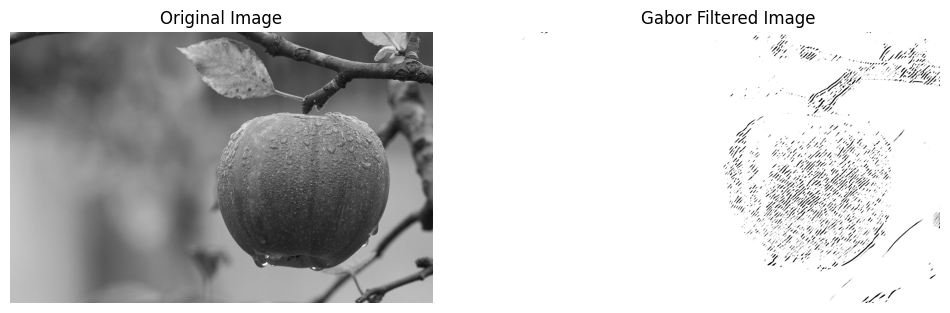

In [2]:
# Step 1: Upload an image
print("Upload a grayscale or color image (e.g., texture, face, fingerprint):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
# Step 2: Read the image in grayscale
gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# Step 3: Create Gabor kernel
kernel = cv2.getGaborKernel(ksize=(21, 21), sigma=8.0, theta=np.pi/4, lambd=10.0, gamma=0.5,
psi=0, ktype=cv2.CV_32F)
# Step 4: Apply Gabor filter
filtered = cv2.filter2D(gray, cv2.CV_8UC3, kernel)
# Step 5: Display original and filtered images side-by-side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered, cmap='gray')
plt.title('Gabor Filtered Image')
plt.axis('off')
plt.show()

Upload a grayscale or color image (texture, face, fingerprint, fabric, etc.):


Saving texture.webp to texture.webp


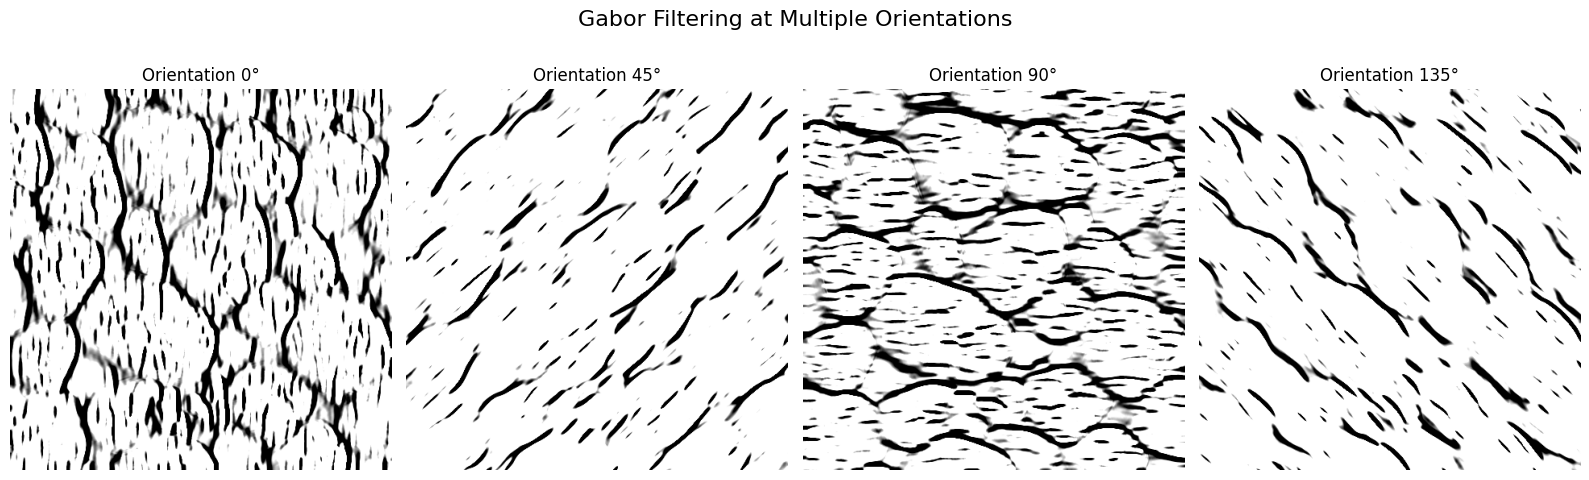

In [4]:
# Step 1: Upload an image
print("Upload a grayscale or color image (texture, face, fingerprint, fabric, etc.):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Step 2: Read image in grayscale
gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# Step 3: Define orientations and apply Gabor filters
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
plt.figure(figsize=(16, 5))
for i, theta in enumerate(orientations):
    kernel = cv2.getGaborKernel((21, 21), 4.0, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
    filtered_img = cv2.filter2D(gray, cv2.CV_8UC3, kernel)
    plt.subplot(1, 4, i+1)
    plt.imshow(filtered_img, cmap='gray')
    plt.title(f"Orientation {int(np.degrees(theta))}°")
    plt.axis('off')
plt.suptitle('Gabor Filtering at Multiple Orientations', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Upload a fingerprint image:


Saving finger.webp to finger.webp


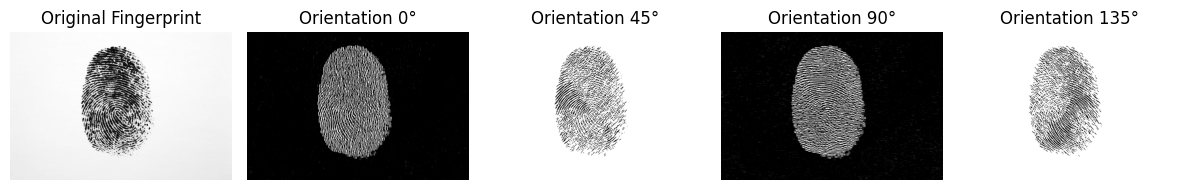

In [9]:
# Step 1: Upload fingerprint image
print("Upload a fingerprint image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
# Step 2: Read the fingerprint image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# Check image loaded
if img is None:
    print("Error loading image.")
else:
    # Step 3: Define Gabor filter parameters (typical for fingerprint ridge enhancement)
    kernel_size = 21
    sigma = 5.0 # Standard deviation of the gaussian envelope
    lambd = 10.0 # Wavelength of the sinusoidal factor
    gamma = 0.5 # Spatial aspect ratio
    psi = 0 # Phase offset
    # Apply Gabor filters at multiple orientations to capture ridge directions
    orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    filtered_imgs = []
    plt.figure(figsize=(12, 6))
    plt.subplot(1, len(orientations)+1, 1)
    plt.title("Original Fingerprint")
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    for i, theta in enumerate(orientations):
        kernel = cv2.getGaborKernel((kernel_size, kernel_size), sigma, theta, lambd, gamma, psi,
        ktype=cv2.CV_32F)
        filtered_img = cv2.filter2D(img, cv2.CV_8UC3, kernel)
        filtered_imgs.append(filtered_img)
        plt.subplot(1, len(orientations)+1, i+2)
        plt.title(f"Orientation {int(np.degrees(theta))}°")
        plt.imshow(filtered_img, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from google.colab import files
import os
def gabor_features(img, kernels):
    """Extract Gabor features from an image using multiple kernels."""
    features = []
    for kernel in kernels:
        filtered = cv2.filter2D(img, cv2.CV_8UC3, kernel)
        mean = filtered.mean()
        variance = filtered.var()
        features.extend([mean, variance])
    return features
# Step 1: Upload texture dataset zip (organized in folders by class)
print("Upload a zipped folder containing texture images organized by class (each folder is a class):")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

# Unzip the uploaded dataset
import zipfile
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('texture_dataset')

dataset_path = 'texture_dataset' # Root folder of extracted dataset
# Step 2: Create Gabor kernels at different orientations and frequencies
kernel_size = 21
sigmas = [4.0, 6.0]
lambdas = [10.0, 15.0]
gammas = [0.5]
psis = [0]
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
kernels = []
for sigma in sigmas:
    for lambd in lambdas:
        for gamma in gammas:
            for psi in psis:
                for theta in orientations:
                    kernel = cv2.getGaborKernel((kernel_size, kernel_size), sigma, theta, lambd, gamma,
                    psi, ktype=cv2.CV_32F)
                    kernels.append(kernel)
# Step 3: Load images and extract features
X = []
y = []
label_map = {}
label_id = 0

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        label_map[label_id] = class_name
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                features = gabor_features(img, kernels)
                X.append(features)
                y.append(label_id)
        label_id += 1
X = np.array(X)
y = np.array(y)

# Step 4: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 5: Train classifier (SVM)
clf = SVC(kernel='linear')
clf.fit(X_train, y_train)
# Step 6: Predict and evaluate
y_pred = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[label_map[i] for i in np.unique(y)]))
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
# Step 7: Visualize some example images with predicted labels
plt.figure(figsize=(12, 6))
for i in range(min(6, len(X_test))):
    # We have feature vectors; show corresponding images from test set manually (optional)
    # Here, just printing predicted labels
    plt.subplot(2, 3, i+1)
    plt.text(0.5, 0.5, f"Class: {label_map[y_pred[i]]}", fontsize=12, ha='center')
    plt.axis('off')
plt.suptitle('Sample Predicted Labels')
plt.show()

Upload a zipped folder containing texture images organized by class (each folder is a class):
